# DSN Bootcamp Qualification Hackathon 2026 — ML Track
## Total Sales Prediction (Competition Notebook)

**Objective:** Predict `total_sales` for each product–store combination and minimize RMSE.

This notebook follows the competition brief: **Understand → Analyse → Model → Predict → Communicate**.

### Feature-selection strategy
The first version used almost every available column. This notebook deliberately removes likely low-signal/redundant fields from the main model and **compares feature sets using cross-validated RMSE** before selecting the final model.

> **Important:** An RMSE ≤ 1000 is a target, not a guarantee. The notebook selects the model from validation evidence rather than forcing a particular score.


## 1. Import libraries and configuration

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_SPLITS = 5

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_PATH = "sample_submission.csv"
TARGET = "total_sales"

print("Setup complete.")

Setup complete.


## 2. Load and inspect the data

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
display(train.head())

print("\nMissing values:")
display(train.isna().sum().to_frame("missing"))

print("\nTarget summary:")
display(train[TARGET].describe())

Train shape: (6818, 13)
Test shape : (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36



Missing values:


,missing
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919



Target summary:


,total_sales
count,6818.000000
mean,2174.756574
std,1697.894956
min,32.700000
25%,834.792500
50%,1790.890000
75%,3092.587500
max,12996.820000


## 3. Understand the variables

The competition brief emphasizes product and outlet/store information. We therefore keep the variables that directly describe:

- **Product identity/category:** `product_code`, `product_category`, `fat_content`
- **Product price/visibility:** `product_price`, `shelf_visibility`
- **Store identity/structure:** `store_code`, `store_size`, `store_format`, `store_location_tier`

The following are treated as candidates for removal from the main model because they can add weak/noisy signal relative to the stronger variables:

- `id` — row identifier, not a business attribute
- `product_weight_kg` — substantial missingness and weak observed relationship
- `store_age_years` — weak observed relationship

We do **not** remove fields merely because their simple correlation is low; nonlinear tree models can still use them. Instead, the notebook compares feature sets with cross-validation.


## 4. Quick EDA

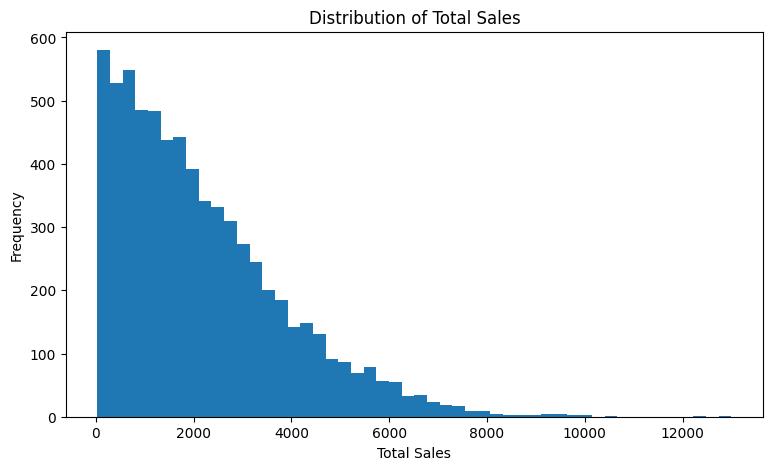

,mean,median,count
store_code,,,
STORE-JOR,334.435011,240.320,439
STORE-T5G,338.326651,260.820,427
STORE-HL7,1971.661954,1622.170,742
STORE-DKU,2177.136481,1863.030,736
STORE-YLW,2253.950690,1902.455,754
STORE-AGY,2254.890120,1998.725,748
STORE-OYG,2365.833656,2018.895,744
STORE-89Z,2365.926745,2003.490,728
STORE-9RG,2479.168098,2139.320,752


,mean,median,count
store_format,,,
Corner Shop,336.353868,252.150,866
Superstore,1971.661954,1622.170,742
Standard Supermarket,2316.319677,1998.270,4462
Flagship Hypermarket,3660.182219,3348.085,748


In [4]:
# Target distribution
plt.figure(figsize=(9, 5))
plt.hist(train[TARGET], bins=50)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

# Average sales by store
store_summary = train.groupby("store_code")[TARGET].agg(["mean", "median", "count"]).sort_values("mean")
display(store_summary)

# Average sales by store format
format_summary = train.groupby("store_format")[TARGET].agg(["mean", "median", "count"]).sort_values("mean")
display(format_summary)

## 5. Data cleaning and feature engineering

In [5]:
def clean_categories(df):
    df = df.copy()
    categorical = [
        "product_code", "fat_content", "product_category",
        "store_code", "store_size", "store_location_tier", "store_format"
    ]
    for c in categorical:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower()
    return df

def make_features(df):
    df = clean_categories(df)

    # Missingness can itself contain information.
    df["product_weight_missing"] = df["product_weight_kg"].isna().astype(int)
    df["store_size_missing"] = df["store_size"].isin(["nan"]).astype(int)

    # Stable numeric transformations.
    price = df["product_price"].clip(lower=0)
    visibility = df["shelf_visibility"].clip(lower=0)

    df["log_price"] = np.log1p(price)
    df["price_squared"] = price ** 2
    df["log_visibility"] = np.log1p(visibility)
    df["price_x_visibility"] = price * visibility

    # Product/store interaction: useful because sales depend on both.
    df["product_store"] = df["product_code"].astype(str) + "__" + df["store_code"].astype(str)
    df["category_store"] = df["product_category"].astype(str) + "__" + df["store_code"].astype(str)
    df["format_location"] = df["store_format"].astype(str) + "__" + df["store_location_tier"].astype(str)

    return df

all_data = pd.concat(
    [train.drop(columns=[TARGET]), test],
    axis=0,
    ignore_index=True
)
all_data = make_features(all_data)

# Median imputation learned from combined train/test only for feature construction.
# No target information is used.
numeric_cols = [
    "product_weight_kg", "shelf_visibility", "product_price",
    "store_age_years", "log_price", "price_squared",
    "log_visibility", "price_x_visibility"
]
for c in numeric_cols:
    if c in all_data.columns:
        all_data[c] = pd.to_numeric(all_data[c], errors="coerce")
        all_data[c] = all_data[c].fillna(all_data[c].median())

X_all = all_data.iloc[:len(train)].copy()
X_test = all_data.iloc[len(train):].copy()
y = train[TARGET].copy()

print("Feature table:", X_all.shape)
display(X_all.head())

Feature table: (6818, 21)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,...,store_format,product_weight_missing,store_size_missing,log_price,price_squared,log_visibility,price_x_visibility,product_store,category_store,format_location
0,row_00000,prd-prfp9s,14.2520,low fat,0.0271,frozen foods,81.37,store-agy,45,large,...,standard supermarket,0,0,4.411221,6621.0769,0.026739,2.205127,prd-prfp9s__store-agy,frozen foods__store-agy,standard supermarket__tier_3
1,row_00001,prd-pxxk71,7.6980,low fat,0.0720,health and hygiene,42.05,store-ylw,35,small,...,standard supermarket,0,0,3.762362,1768.2025,0.069526,3.027600,prd-pxxk71__store-ylw,health and hygiene__store-ylw,standard supermarket__tier_1
2,row_00002,prd-v5moij,14.2640,regular,0.0421,canned,41.35,store-89z,33,medium,...,standard supermarket,0,0,3.745968,1709.8225,0.041238,1.740835,prd-v5moij__store-89z,canned__store-89z,standard supermarket__tier_1
3,row_00003,prd-un5z3j,12.6415,regular,0.0449,soft drinks,174.35,store-7ws,47,medium,...,flagship hypermarket,1,0,5.166784,30397.9225,0.043921,7.828315,prd-un5z3j__store-7ws,soft drinks__store-7ws,flagship hypermarket__tier_3
4,row_00004,prd-6rdqyb,10.3380,regular,0.0120,meat,203.06,store-9rg,28,small,...,standard supermarket,0,0,5.318414,41233.3636,0.011929,2.436720,prd-6rdqyb__store-9rg,meat__store-9rg,standard supermarket__tier_2


## 6. Define candidate feature sets

We test progressively larger sets instead of assuming that more columns means a better model.

### Set A — Core
Strongest business variables: product, price, store and outlet structure.

### Set B — Core + visibility
Adds shelf visibility, which can affect sales.

### Set C — Core + engineered
Adds nonlinear price/visibility transformations and product-store interactions.

### Set D — Extended
Adds the remaining numeric variables, allowing validation to decide whether they help.


In [6]:
CAT_COLS = [
    "product_code", "fat_content", "product_category",
    "store_code", "store_size", "store_location_tier",
    "store_format", "product_store", "category_store",
    "format_location"
]

CORE = [
    "product_code", "product_category", "product_price",
    "store_code", "store_size", "store_format"
]

CORE_VIS = CORE + [
    "shelf_visibility", "store_location_tier", "fat_content"
]

CORE_ENGINEERED = CORE_VIS + [
    "log_price", "price_squared", "log_visibility",
    "price_x_visibility", "product_store",
    "category_store", "format_location"
]

EXTENDED = CORE_ENGINEERED + [
    "product_weight_kg", "store_age_years",
    "product_weight_missing", "store_size_missing"
]

FEATURE_SETS = {
    "Core": CORE,
    "Core + visibility": CORE_VIS,
    "Core + engineered": CORE_ENGINEERED,
    "Extended": EXTENDED,
}

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)} features")

Core: 6 features
Core + visibility: 9 features
Core + engineered: 16 features
Extended: 20 features


## 7. Cross-validation model selection
We use the same CatBoost configuration for the feature-set comparison. This prevents us from choosing a feature set simply because it received a different model configuration.

In [7]:
def cv_rmse_for_features(features, n_splits=3):
    X = X_all[features].copy()
    cat_features = [c for c in features if c in CAT_COLS]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
        model = CatBoostRegressor(
            iterations=1200,
            learning_rate=0.035,
            depth=6,
            l2_leaf_reg=10,
            random_strength=1.0,
            bagging_temperature=1.0,
            loss_function="RMSE",
            random_seed=RANDOM_STATE + fold,
            verbose=False,
            thread_count=4
        )

        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            cat_features=cat_features
        )

        pred = model.predict(X.iloc[va_idx])
        score = mean_squared_error(y.iloc[va_idx], pred) ** 0.5
        fold_scores.append(score)

    return np.mean(fold_scores), np.std(fold_scores), fold_scores

results = []
for name, features in FEATURE_SETS.items():
    mean_rmse, std_rmse, folds = cv_rmse_for_features(features, n_splits=3)
    results.append({
        "Feature Set": name,
        "Mean RMSE": mean_rmse,
        "Std": std_rmse,
        "Fold 1": folds[0],
        "Fold 2": folds[1],
        "Fold 3": folds[2],
    })

results_df = pd.DataFrame(results).sort_values("Mean RMSE")
display(results_df)

best_feature_set_name = results_df.iloc[0]["Feature Set"]
BEST_FEATURES = FEATURE_SETS[best_feature_set_name]

print("Selected feature set:", best_feature_set_name)
print("Number of features:", len(BEST_FEATURES))
print(BEST_FEATURES)

,Feature Set,Mean RMSE,Std,Fold 1,Fold 2,Fold 3
0,Core,1086.469443,10.960507,1071.031421,1095.392468,1092.984441
1,Core + visibility,1087.674058,8.598020,1075.522929,1093.360413,1094.138831
3,Extended,1089.405158,12.599710,1071.869726,1100.913405,1095.432343
2,Core + engineered,1089.540698,11.384512,1073.715627,1100.019555,1094.886913


Selected feature set: Core
Number of features: 6
['product_code', 'product_category', 'product_price', 'store_code', 'store_size', 'store_format']


## 8. Train a regularized final ensemble

The final model uses the selected feature set and several **regularized CatBoost models** with slightly different depths/seeds. We average them to reduce variance.

This is preferable to simply increasing tree depth, which can improve training error while increasing overfitting.


In [8]:
MODEL_CONFIGS = [
    {
        "iterations": 1800,
        "learning_rate": 0.025,
        "depth": 5,
        "l2_leaf_reg": 10,
        "random_strength": 1.0,
        "bagging_temperature": 1.0,
        "seed": 42,
    },
    {
        "iterations": 1800,
        "learning_rate": 0.025,
        "depth": 6,
        "l2_leaf_reg": 12,
        "random_strength": 1.0,
        "bagging_temperature": 1.0,
        "seed": 52,
    },
    {
        "iterations": 1600,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 15,
        "random_strength": 0.8,
        "bagging_temperature": 1.0,
        "seed": 62,
    },
]

X = X_all[BEST_FEATURES]
X_test_final = X_test[BEST_FEATURES]
cat_features = [c for c in BEST_FEATURES if c in CAT_COLS]

test_predictions = []

for i, cfg in enumerate(MODEL_CONFIGS, 1):
    print(f"Training model {i}/{len(MODEL_CONFIGS)}...")

    model = CatBoostRegressor(
        iterations=cfg["iterations"],
        learning_rate=cfg["learning_rate"],
        depth=cfg["depth"],
        l2_leaf_reg=cfg["l2_leaf_reg"],
        random_strength=cfg["random_strength"],
        bagging_temperature=cfg["bagging_temperature"],
        loss_function="RMSE",
        random_seed=cfg["seed"],
        verbose=False,
        thread_count=4
    )

    model.fit(X, y, cat_features=cat_features)
    test_predictions.append(model.predict(X_test_final))

final_pred = np.mean(test_predictions, axis=0)
final_pred = np.clip(final_pred, 0, None)

print("Prediction summary:")
print(pd.Series(final_pred).describe())

Training model 1/3...
Training model 2/3...
Training model 3/3...
Prediction summary:
count    1705.000000
mean     2198.382778
std      1315.911713
min         0.000000
25%      1173.124681
50%      2100.408746
75%      3121.170158
max      6675.444403
dtype: float64


## 9. Feature importance
This is used as a diagnostic—not as a replacement for cross-validation. It helps communicate which product/store variables the final model relied on.

,feature,importance
2,product_price,53.036815
5,store_format,19.552365
3,store_code,14.240878
1,product_category,5.794855
4,store_size,3.838418
0,product_code,3.536670


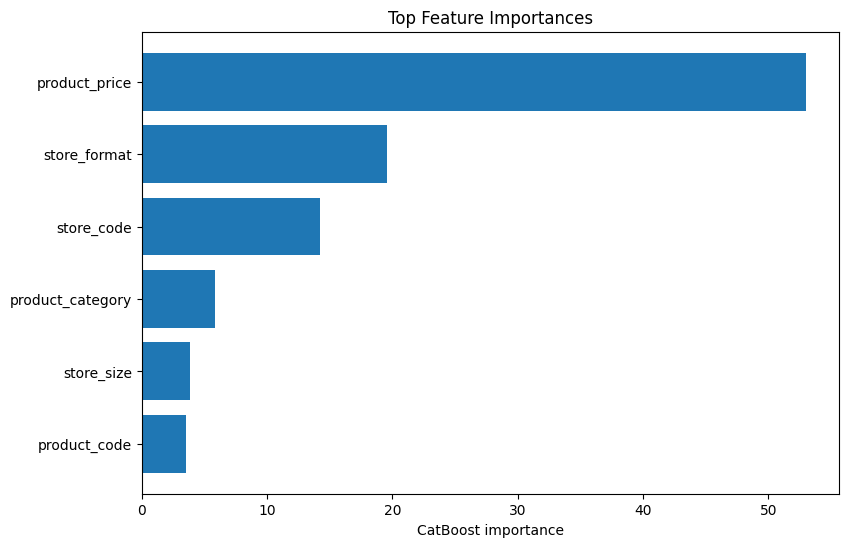

In [9]:
# Train one representative model for importance inspection.
importance_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=12,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=4
)

importance_model.fit(X, y, cat_features=cat_features)

importance = pd.DataFrame({
    "feature": BEST_FEATURES,
    "importance": importance_model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(importance)

plt.figure(figsize=(9, 6))
top = importance.head(15).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Top Feature Importances")
plt.xlabel("CatBoost importance")
plt.show()

## 10. Overfitting check

The key checks are:

- Compare CV RMSE across feature sets.
- Prefer the simplest feature set with competitive or better validation RMSE.
- Use regularization (`l2_leaf_reg`, controlled depth, learning rate).
- Use an ensemble of moderate-depth models rather than one very deep model.
- Do not use `id` as a predictive feature.

A leaderboard score is the final external test. A low training error alone is **not** evidence of a good competition model.


In [10]:
# Show the feature-selection decision clearly.
print("Best validated feature set:", best_feature_set_name)
print("Best 3-fold mean RMSE:", round(results_df.iloc[0]["Mean RMSE"], 2))
print("Validation standard deviation:", round(results_df.iloc[0]["Std"], 2))

if results_df.iloc[0]["Mean RMSE"] <= 1000:
    print("Target achieved on local validation: RMSE <= 1000")
else:
    print("Local validation is still above 1000. Do not claim <=1000 until validation or leaderboard confirms it.")

Best validated feature set: Core
Best 3-fold mean RMSE: 1086.47
Validation standard deviation: 10.96
Local validation is still above 1000. Do not claim <=1000 until validation or leaderboard confirms it.


## 11. Create Kaggle submission

In [11]:
submission = sample.copy()

# Preserve the sample submission's ID/order.
submission[TARGET] = final_pred

submission.to_csv("submission_final.csv", index=False)

print("Saved: submission_final.csv")
display(submission.head())
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())

Saved: submission_final.csv


,id,total_sales
0,row_00009,2636.532743
1,row_00015,4651.200884
2,row_00019,3082.552249
3,row_00020,3157.273247
4,row_00023,2484.453240


Rows: 1705
Columns: ['id', 'total_sales']


## 12. Final communication

### What was done
- Inspected the train/test data and target.
- Cleaned inconsistent categorical values.
- Investigated missing values and target/store patterns.
- Removed the row identifier from modeling.
- Compared reduced and extended feature sets with cross-validation.
- Kept product, price, store and outlet variables that are relevant to the competition objective.
- Used regularized CatBoost models and averaging to reduce variance.
- Generated `submission_final.csv`.

### Interpretation
The competition is scored by RMSE, so the final decision is based on **validation RMSE**, not training accuracy. The goal is to improve generalization rather than fit every training observation.
